# Machine Learning LAB 1: MODEL SELECTION

Course 2024/25: *F. Chiariotti*

The notebook contains a simple learning task over which we will implement **MODEL SELECTION AND VALIDATION**.

Complete all the **required code sections** and **answer all the questions**.

## Timing:
### Ex.1 --> 15.45 - 16. 30 (Helper functions)
### Ex.2 --> 16.30 - 18.30 (K-cross)
### Ex.3 --> 18.30 - 19.30 (Other methods)


## Polynomial Classification on Signal to Noise Ratios

In this notebook we are going to explore the use of polynomial classification with polynomial regression. We are going to use the Numpy **polyfit** function, which performs polynomial regression.

Our use case is a communication problem: we have a set of measurements of the Signal to Noise Ratio (SNR), i.e., the quality of the communication link, in various positions. The SNR depends on two components: firstly, the noise level (which is a random variable that does not depend on position) and the signal attenuation (usually modeled as a polynomial function of the distance).

Our transmitter is in (0,0), and coordinates are in meters. In urban scenarios, the attenuation usually follows a third-degree polynomial, but it might be a fourth- or fifth-degree polynomial in more complex cases. How do we choose between different degrees? We will try with a maximum of **6**

---

## Import all the necessary Python libraries

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import itertools
import random 
from matplotlib import pyplot as plt

---

## Load the data

In this case, x and y are the two coordinates, and the SNR is the thing we are trying to predict

**DO NOT CHANGE THE PRE-WRITTEN CODE UNLESS OTHERWISE SPECIFIED**

In [2]:
df = pd.read_csv('data/snr_measurements.csv',sep=';')
x = df['x'].to_numpy()
y = df['y'].to_numpy()
SNR = df['SNR'].to_numpy()
print(np.shape(x))
print(np.shape(y))
print(np.shape(SNR))

(200,)
(200,)
(200,)


## Helper functions

These functions will help us evaluate the results

In [3]:
def compute_distance(x, y):
    # TODO: Compute the Euclidean distance from the origin
    distance = np.sqrt(x**2 + y**2)
    return distance

def fit(distance, SNR, degree):
    return np.polyfit(distance, SNR, deg=degree)

def predict(distance, poly_coeffs):
    # TODO: Predict the SNR from a given model
    poly_coeffs = list(reversed(poly_coeffs)) #so they're ordered from 0 to deg
    pred = 0
    for exp in range (len(poly_coeffs)): 
        pred += poly_coeffs[exp] * (distance ** exp)
    return pred

def evaluate(distance, SNR, poly_coeffs):
    # TODO: Compute the error of the polynomial fit on the chosen data
    mse = sum((predict(distance,poly_coeffs)-SNR)**2)/len(SNR)
    return mse

def separate_test(distance, SNR, test_points):
    # TODO: Return a training set and a test set (the test_points parameter controls the number of test points).
    # The points should be selected randomly
    # Notice that here x is the distance and y is SNR
    idx = list(range(len(x)))
    test_idx = random.sample(idx, test_points)
    train_idx = [i for i in idx if i not in test_idx]
    x_train = distance[train_idx]
    x_test = distance[test_idx]
    y_train = SNR[train_idx]
    y_test = SNR[test_idx]
    return x_train, y_train, x_test, y_test

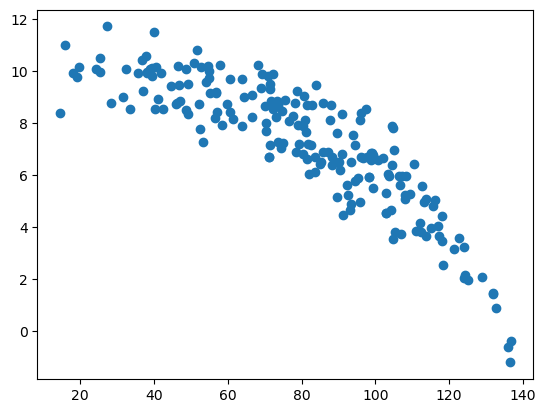

In [4]:
# TODO: separate the training and test sets and create a scatter plot of the SNR as a function of the distance
#import math
#test_points = math.floor(0.25*len(SNR))
test_points = 40
distance = compute_distance(x,y)
x_train, y_train, x_test, y_test = separate_test(distance,SNR,test_points)

plt.scatter(distance,SNR)

## A. K-fold cross-validation

In this case, x and y are the two coordinates, and the SNR is the thing we are trying to predict

In [5]:
## Function to perform the K-fold cross validation
def k_fold_cross_validation(x_train: np.ndarray, y_train: np.ndarray, k: int, max_degree: int):
    # TODO: Perform K-fold cross-validation on the training set.
    # The two returned values are the best model and the list of results for all degrees up to max_degree.
    # The points should be selected randomly.
    # The inputs and labels are already in terms of distance and SNR

    # Divide training set in K folds
    x_folds = [] # Will contain the data of the different folds. So x_fold[i] is the data of the ith fold
    y_folds = []
    fold_points = int(np.floor(len(x_train) / k))
    idx = list(range(len(x_train)))
    for i in range(k):
        fold_idx = random.sample(idx, fold_points)
        idx = [i for i in idx if i not in fold_idx]
        x_folds.append(x_train[fold_idx])
        y_folds.append(y_train[fold_idx])

    #Training and validation
    results = [] # List of degree's performances
    best_perf = 1e20
    
    for deg in range(max_degree + 1): 
        degree_perf = 0
        for test in range(k): 
            x_train_fold = [x for i,x in enumerate(x_folds) if i != test]
            y_train_fold = [x for i,x in enumerate (y_folds) if i != test]
            x_train_fold = np.concatenate(x_train_fold) # Otherwise they'll be separated
            y_train_fold = np.concatenate(y_train_fold)
            x_val_fold = x_folds[test]
            y_val_fold = y_folds[test]
            k_model = fit(x_train_fold, y_train_fold, deg) # You get the best parameters for this degree on this fold
            degree_perf += evaluate(x_val_fold, y_val_fold, k_model) # You evaluate this degree's performance
        degree_perf /= k
        results.append(degree_perf)
        if (best_perf > degree_perf):
            best = fit(x_train, y_train, deg)
            best_perf = degree_perf
        
    return best, results

[-5.26939176e-06  3.74180041e-04 -2.93586904e-02  1.05738020e+01]


Text(0, 0.5, 'MSE')

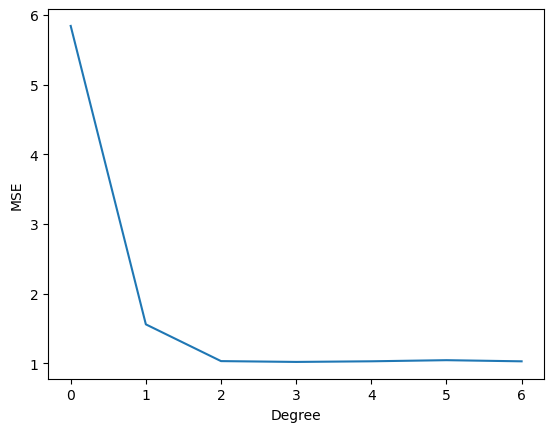

In [6]:
# TODO: run the training with K-fold cross-validation with 40 test points and 4 folds. Plot the validation score as a function of the degree. 
max_degree = 6
K = 4
best, results = k_fold_cross_validation(x_train, y_train, K, max_degree)
print(best)
plt.plot(range(max_degree + 1), results) 
plt.xlabel('Degree')
plt.ylabel('MSE')

### COMMENT:
We can see that after degree 2 there's a "knee". The best model is around 4 (you can see this by printing the best model: it has coefficients up to 4th degree). 
This makes sense because the data was generated with a third degree polynomial with some Gaussian noise. Since we have few data (only 200 points), it's easy for the algorithm to get a little "confused". 

[-5.26939176e-06  3.74180041e-04 -2.93586904e-02  1.05738020e+01] 0.7785468294511084


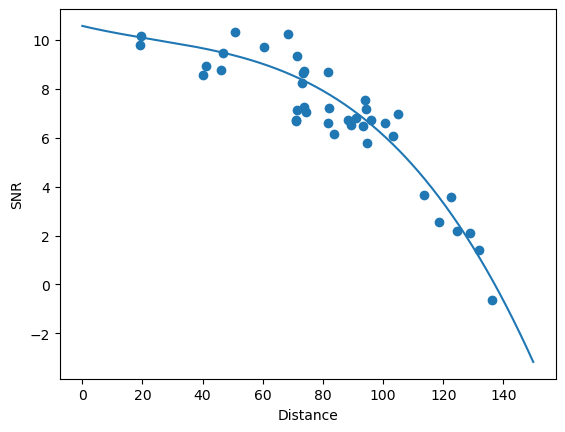

In [7]:
# TODO: get the test performance of the best model and plot the model output and test points. 
# Try running the program multiple times, changing the values of K and the number of test points: is the output always the same?
dist_vals = np.arange(0,150,0.1)
pred_SNR = np.zeros(1500)
for i in range(1500):
    pred_SNR[i] = predict(dist_vals[i], best)

print(best, evaluate(x_test, y_test, best))

plt.plot(dist_vals, pred_SNR)
plt.scatter(x_test, y_test)
plt.xlabel('Distance')
plt.ylabel('SNR')
plt.show()

### COMMENT: 
- Changing the value of K --> the larger K, the higher the degree of the polynomial that we get. Tends to overfit. Is better smaller values of K.
- Having more test points apparently helps.

#### 1. **Why increasing the number of folds gives a worse estimation of the generalization error?**
   - When you increase the number of folds $K$ in K-fold cross-validation, the **training sets become larger** (since fewer points are reserved for validation), and the validation sets become smaller.
   - Smaller validation sets can lead to a **higher variance** in the error estimates because the smaller validation set may not fully represent the underlying data distribution. This causes fluctuations in the validation error and can overfit the model to the training data.
   - In your case, as $K$ increases, **the model becomes more flexible (overfitting), leading to an estimation of a higher-degree polynomial**. This results in lower training error but worse generalization, as the model starts to capture noise in the training data.

#### 2. **Why would the error decrease if you increase the test points?**
   - Increasing the number of test points **reduces the variance in the error estimate because the test set better approximates the true data distribution**.
   - With more test points, the evaluation becomes less sensitive to outliers or noise in the test set. This leads to a more stable and reliable estimate of the generalization error, typically closer to the true error of the model.
   - For a model trained on a polynomial, if the test set is large enough and uniformly distributed over the domain of the data, the test error will tend to stabilize and decrease because it reflects the true expected performance of the model.


## B. Tikhonov regularization

Change the loss function to include a Tikhonov regularization term, as an alternative to cross-validation (try $\lambda=0.01$)

In [8]:
def evaluate_tikhonov(x_train: np.ndarray, y_train: np.ndarray, lambda_par: float, max_degree: int) -> tuple[tuple, tuple]:
    # TODO: apply Tikhonov regularization AFTER the fitting process
    
    results = [] # List of degree's performances
    best_perf = 1e20
    
    for deg in range(max_degree + 1): 
        deg_model = fit(x_train, y_train, deg) # You get the best parameters for this degree on this fold
        degree_perf = evaluate(x_train, y_train, deg_model) + np.sum(deg_model ** 2) * lambda_par # You evaluate this degree's performance with Tikhonov
        results.append(degree_perf)
        if (best_perf > degree_perf):
            best = deg_model
            best_perf = degree_perf
    return best, results
    

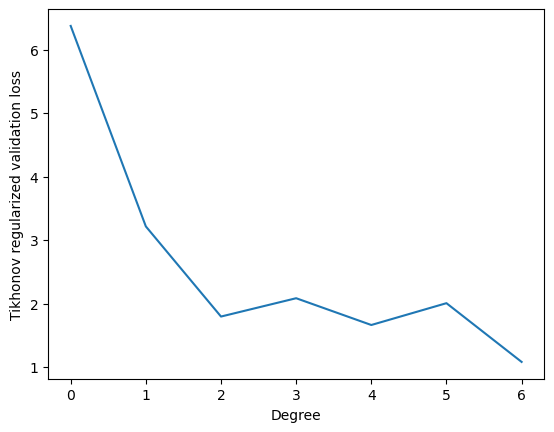

In [9]:
# TODO: run the training with Tikhonov regularization and plot the loss as a function of the degree
lambda_par = 0.01
best_tik, results_tik = evaluate_tikhonov(x_train, y_train, lambda_par, max_degree)

plt.plot(range(max_degree + 1), results_tik) 
plt.xlabel('Degree')
plt.ylabel('Tikhonov regularized validation loss')
plt.show()


## C. Minimum description length regularization

Change the loss function to include a representation length regularization term, as an alternative to cross-validation. The minimum description length of a polynomial of degree N is O(2^N) - try $\lambda=0.02$

In [15]:
def evaluate_representation(x_train: np.ndarray, y_train: np.ndarray, lambda_par: float, max_degree: int) -> tuple[tuple, tuple]:
    # TODO: apply MDL regularization
    
    results = [] # List of degree's performances
    best_perf = 1e20
    
    for deg in range(max_degree + 1): 
        deg_model = fit(x_train, y_train, deg) # You get the best parameters for this degree on this fold
        degree_perf = evaluate(x_train, y_train, deg_model) + 2 ** (deg+1) * lambda_par # You evaluate this degree's performance with MDL
        results.append(degree_perf)
        if (best_perf > degree_perf):
            best = deg_model
            best_perf = degree_perf
            
    return best, results



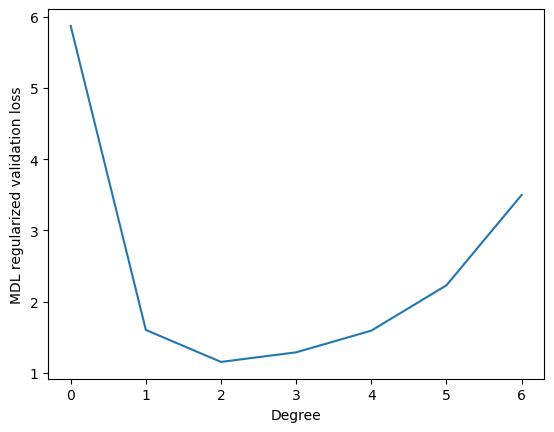

In [16]:
# TODO: run the training with MDL regularization and plot the loss as a function of the degree
lambda_par = 0.02
best_rep, results_rep = evaluate_representation(x_train, y_train, lambda_par, max_degree)

plt.plot(range(max_degree + 1), results_rep) 
plt.xlabel('Degree')
plt.ylabel('MDL regularized validation loss')
plt.show()

### TEST

Check the performance of the three solutions on the test set: which one does best?


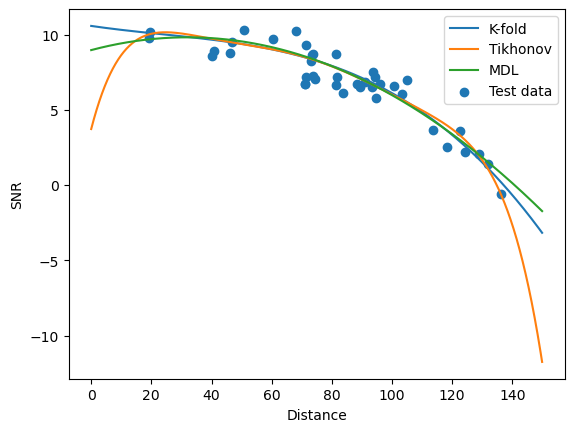

K-fold loss: 0.7785468294511084
Tik loss: 0.7905023429491714
MDL loss: 0.8329813293855601


In [20]:
# TODO: plot the results

dist_vals = np.arange(0,150,0.1)
pred_SNR_Kfold = np.zeros(1500)
pred_SNR_tkh = np.zeros(1500)
pred_SNR_mdl = np.zeros(1500)
for i in range(1500):
    pred_SNR_Kfold[i] = predict(dist_vals[i], best)
    pred_SNR_tkh[i] = predict(dist_vals[i], best_tik)
    pred_SNR_mdl[i] = predict(dist_vals[i], best_rep)

plt.plot(dist_vals, pred_SNR_Kfold)
plt.plot(dist_vals, pred_SNR_tkh)
plt.plot(dist_vals, pred_SNR_mdl)
plt.scatter(x_test, y_test)
plt.xlabel('Distance')
plt.ylabel('SNR')
plt.legend(['K-fold','Tikhonov','MDL','Test data'])
plt.show()

print("K-fold loss:", evaluate(x_test, y_test, best))
print("Tik loss:", evaluate(x_test, y_test, best_tik))
print("MDL loss:",  evaluate(x_test, y_test, best_rep))
      

### COMMENT: 
They only give slightly different results. 